In [29]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('../..')))
from lib.DataCollector import DataCollector
from lib.StochasticFilters import StochasticModels
from datetime import datetime, timedelta
import plotly.graph_objects as go
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pywt
import warnings
warnings.filterwarnings('ignore')
import itertools

In [30]:
sns.set_style('whitegrid')
idx = pd.IndexSlice

### How to use Kalman Filters and Wavelets

In [31]:
# Importing Sample Tickers

tickers = ['AAPL', 'MSFT', 'JPM', 'GS', 'JNJ']

In [32]:
end_date = datetime.now()
YEARS = 5
start_date = end_date - timedelta(days=365 * YEARS)

end_date_str = end_date.strftime('%Y-%m-%d')
start_date_str = start_date.strftime('%Y-%m-%d')

In [33]:
data_collector = DataCollector(tickers, start_date_str, end_date_str)
stock_data = data_collector.fetch_data()
stock_data = {ticker: data_collector.add_technical_indicators(df) for ticker, df in stock_data.items()}

Fetching stock data...
Successfully fetched 5 stocks
Failed to fetch 0 stocks


In [34]:
stochastic_models = StochasticModels()


In [35]:
def plot_price_data(ticker):
    df = stock_data[ticker]
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=df.index,
        y=df['close'],
        mode='lines',
        name='Close Price',
        line=dict(color='blue', width=2)
    ))

    fig.add_trace(go.Scatter(
        x=df.index,
        y=df['close_kalman'],
        mode='lines',
        name='Kalman Filtered Price',
        line=dict(color='green', width=2, dash='dash')
    ))

    fig.add_trace(go.Scatter(
        x=df.index,
        y=df['sma_30'],
        mode='lines',
        name='SMA 30',
        opacity=0.5,
        line=dict(color='red', width=2)
    ))

    fig.add_trace(go.Scatter(
        x=df.index,
        y=df['sma_60'],
        mode='lines',
        name='SMA 60',
        opacity=0.5,
        line=dict(color='orange', width=2)
    ))
    fig.add_trace(go.Scatter(
        x=df.index,
        y=df['sma_90'],
        mode='lines',
        name='SMA 90',
        opacity=0.5,
        line=dict(color='purple', width=2)
    ))

    fig.update_layout(
        title=f'{ticker} Close Price Over Time',
        xaxis_title='Date',
        yaxis_title='Price (USD)',
        plot_bgcolor='rgba(240, 240, 240, 0.5)',
        xaxis_rangeslider_visible=False
    )
    
    fig.show()

In [36]:
stock_data = {ticker: stochastic_models.apply_kalman_filter(df = df, column='close') for ticker, df in stock_data.items()}

for ticker, df in stock_data.items():
    print(f"Plotting price data for {ticker}")
    plot_price_data(ticker)

Plotting price data for AAPL


Plotting price data for MSFT


Plotting price data for JPM


Plotting price data for GS


Plotting price data for JNJ


### Wavelets


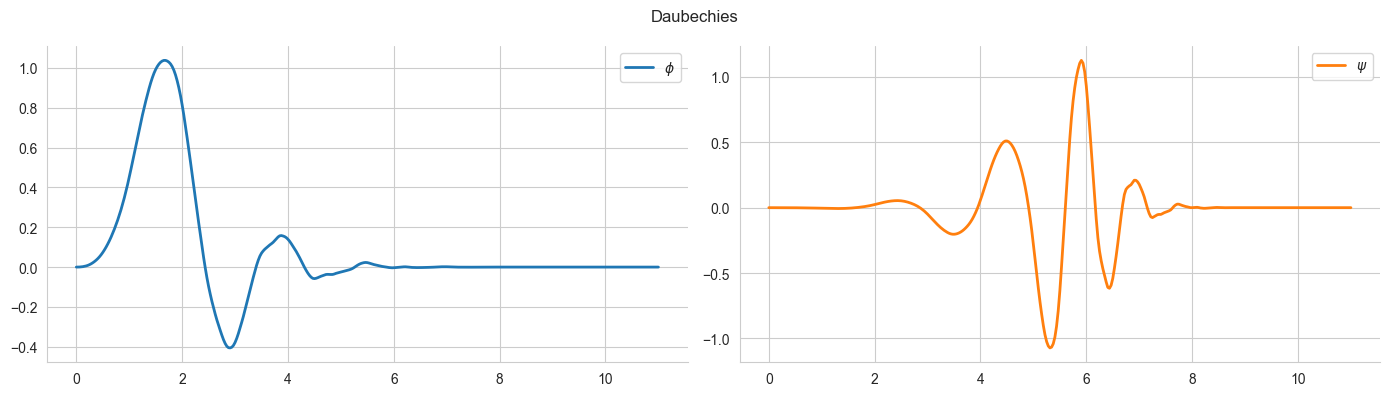

In [37]:
wavelet = pywt.Wavelet('db6')
phi, psi, x = wavelet.wavefun(level=5)
df = pd.DataFrame({'$\phi$': phi, '$\psi$': psi}, index=x)
df.plot(title='Daubechies', subplots=True, layout=(1, 2), figsize=(14, 4), lw=2, rot=0)
plt.tight_layout()
sns.despine();

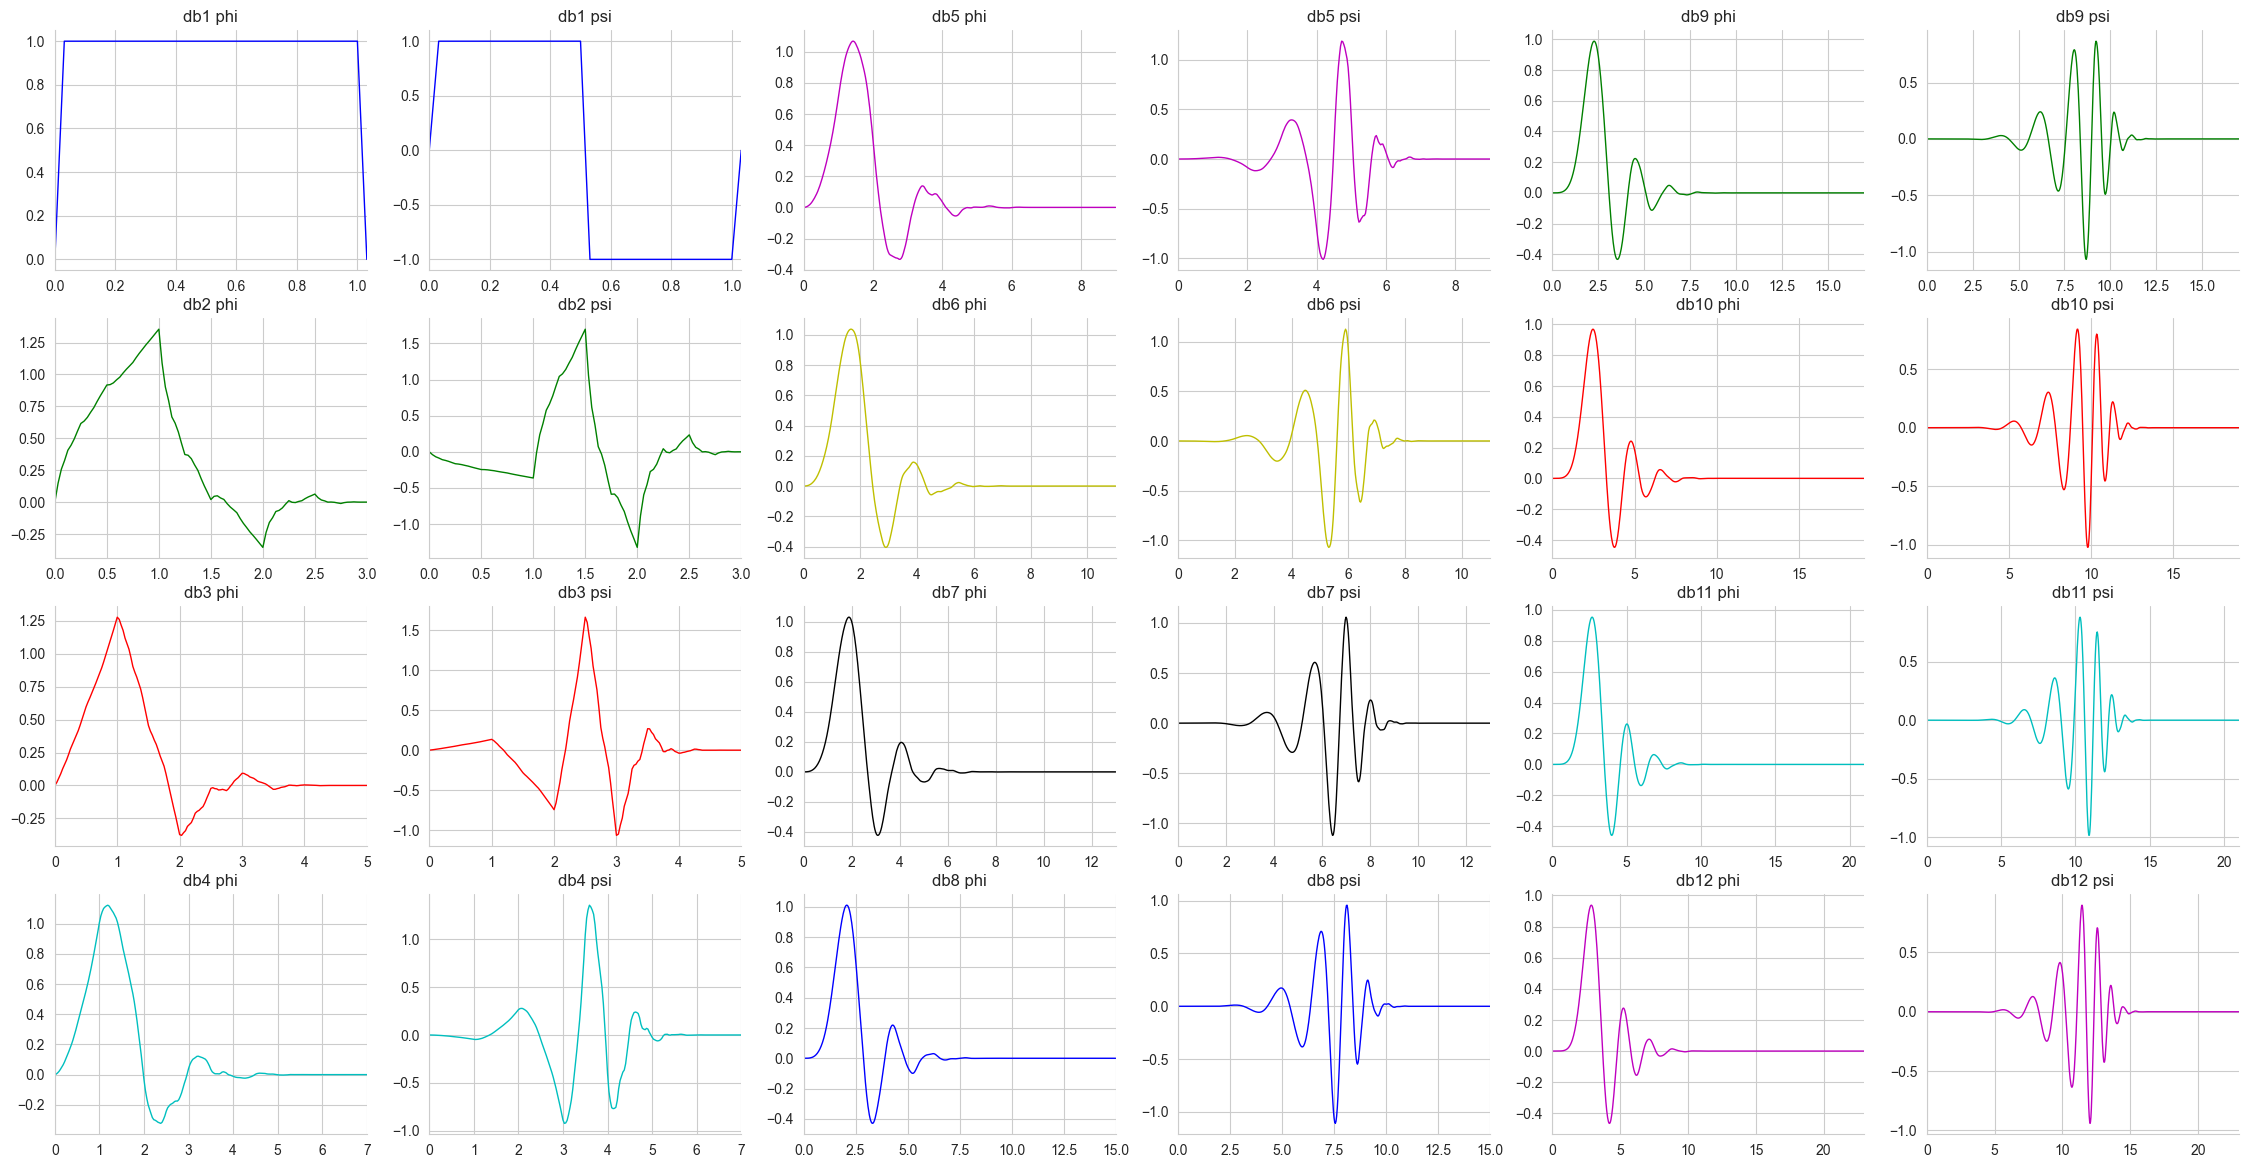

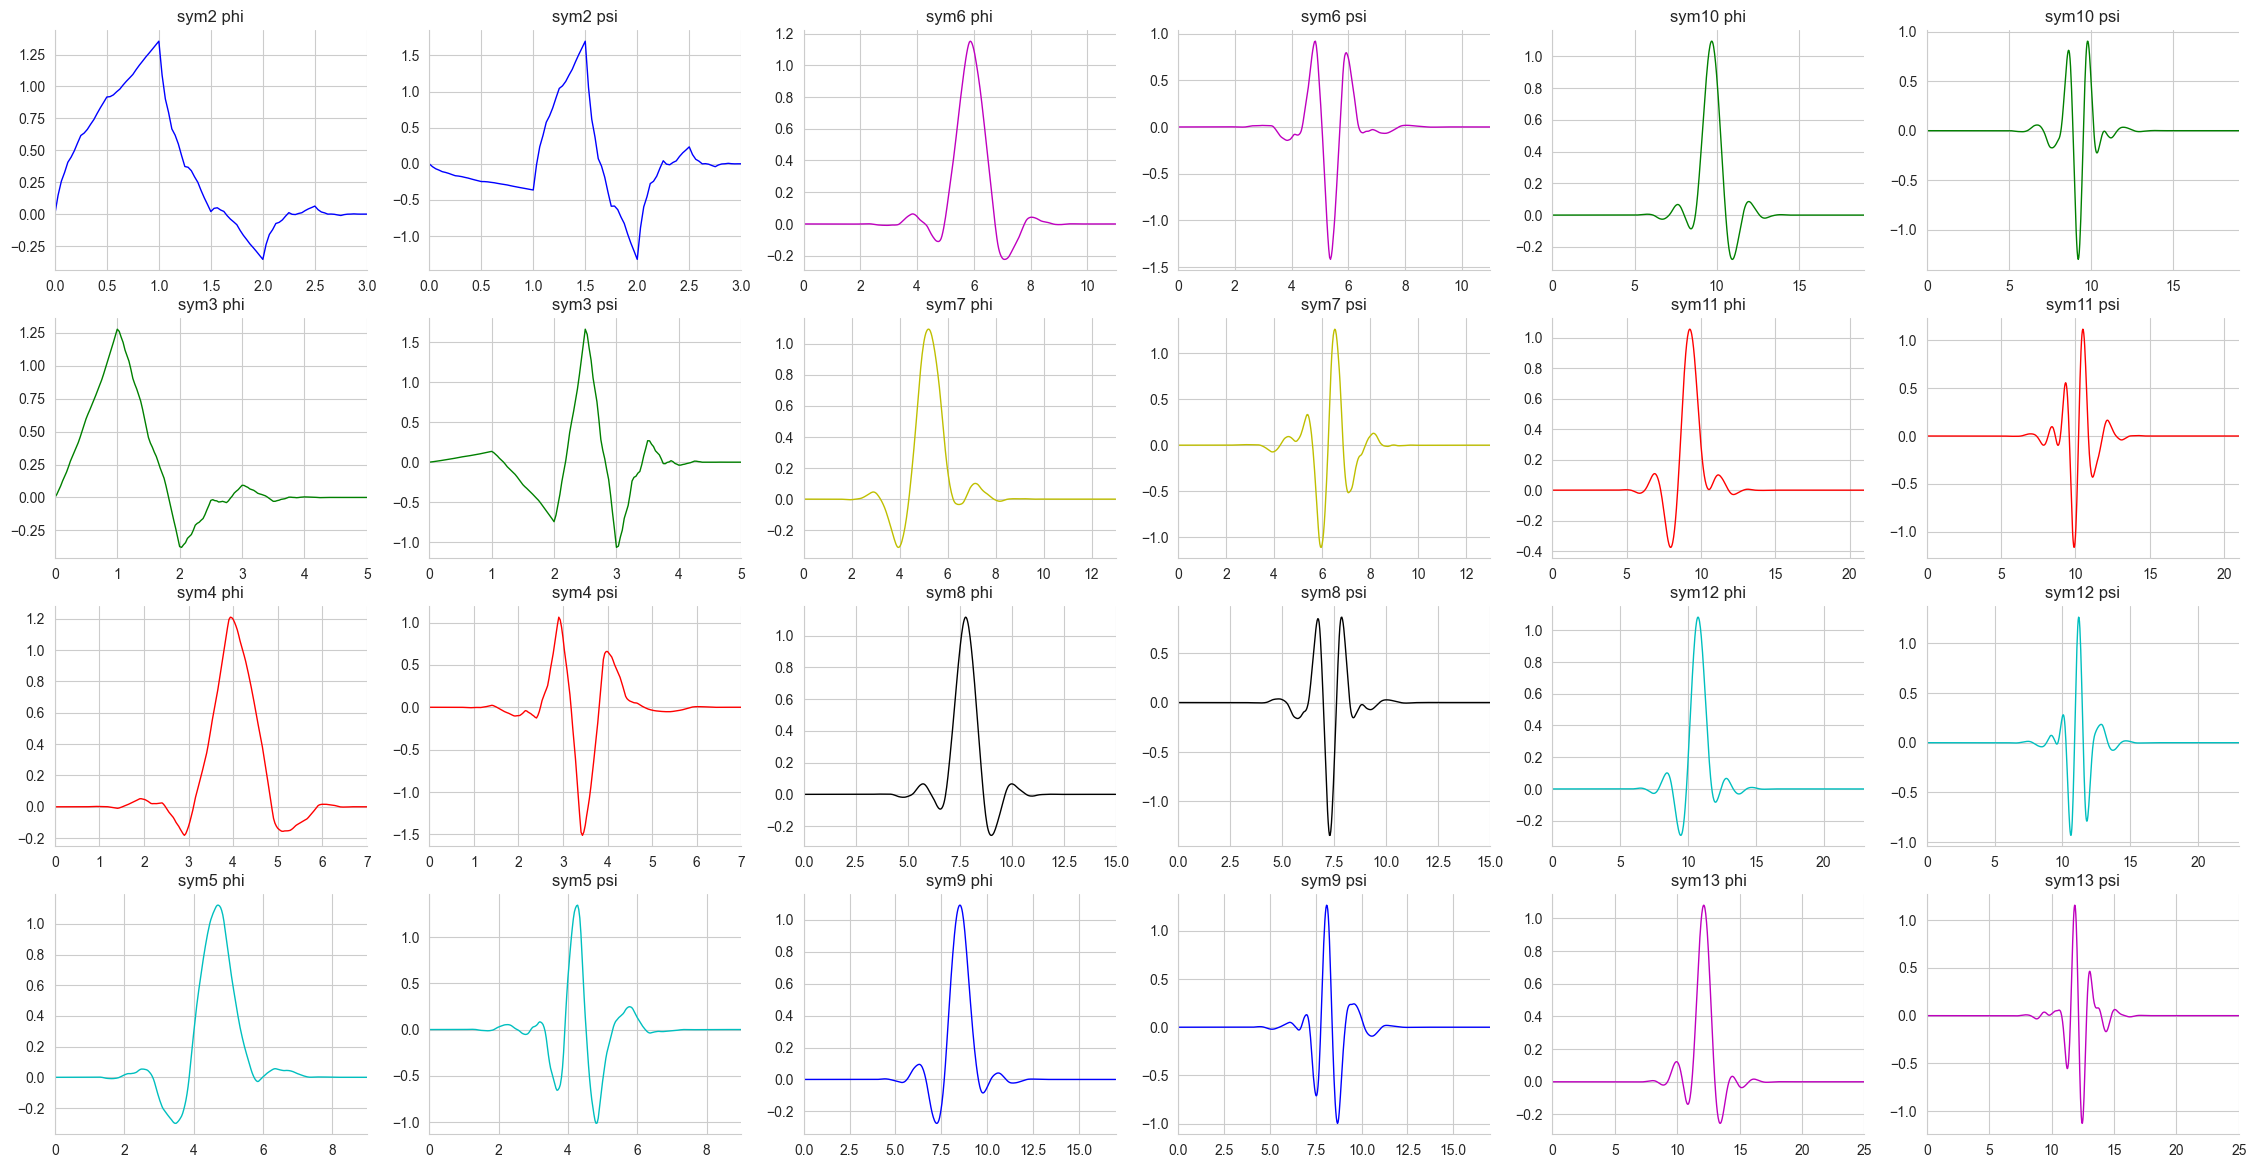

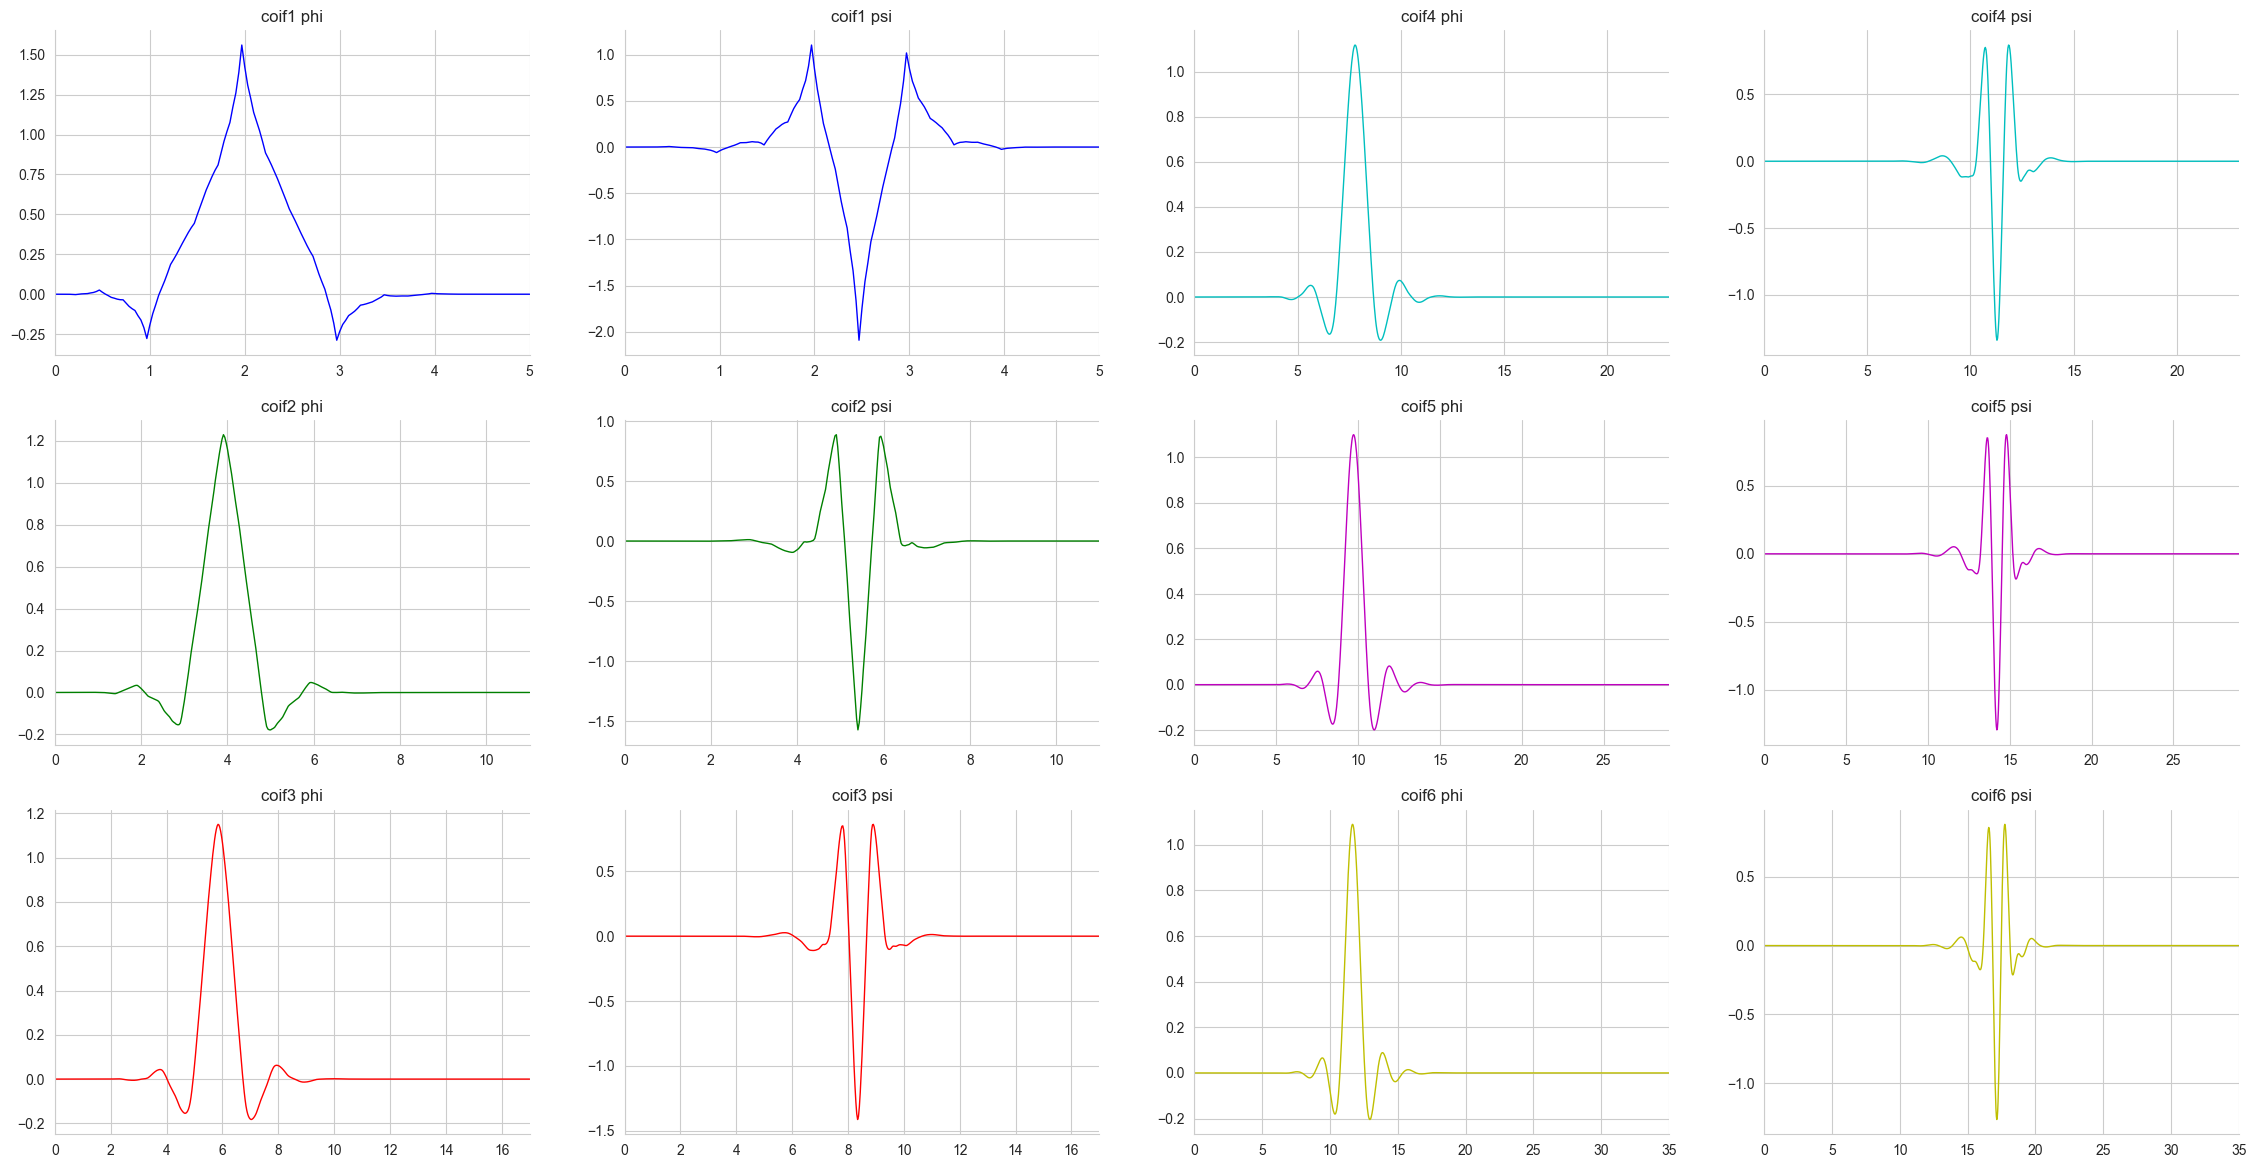

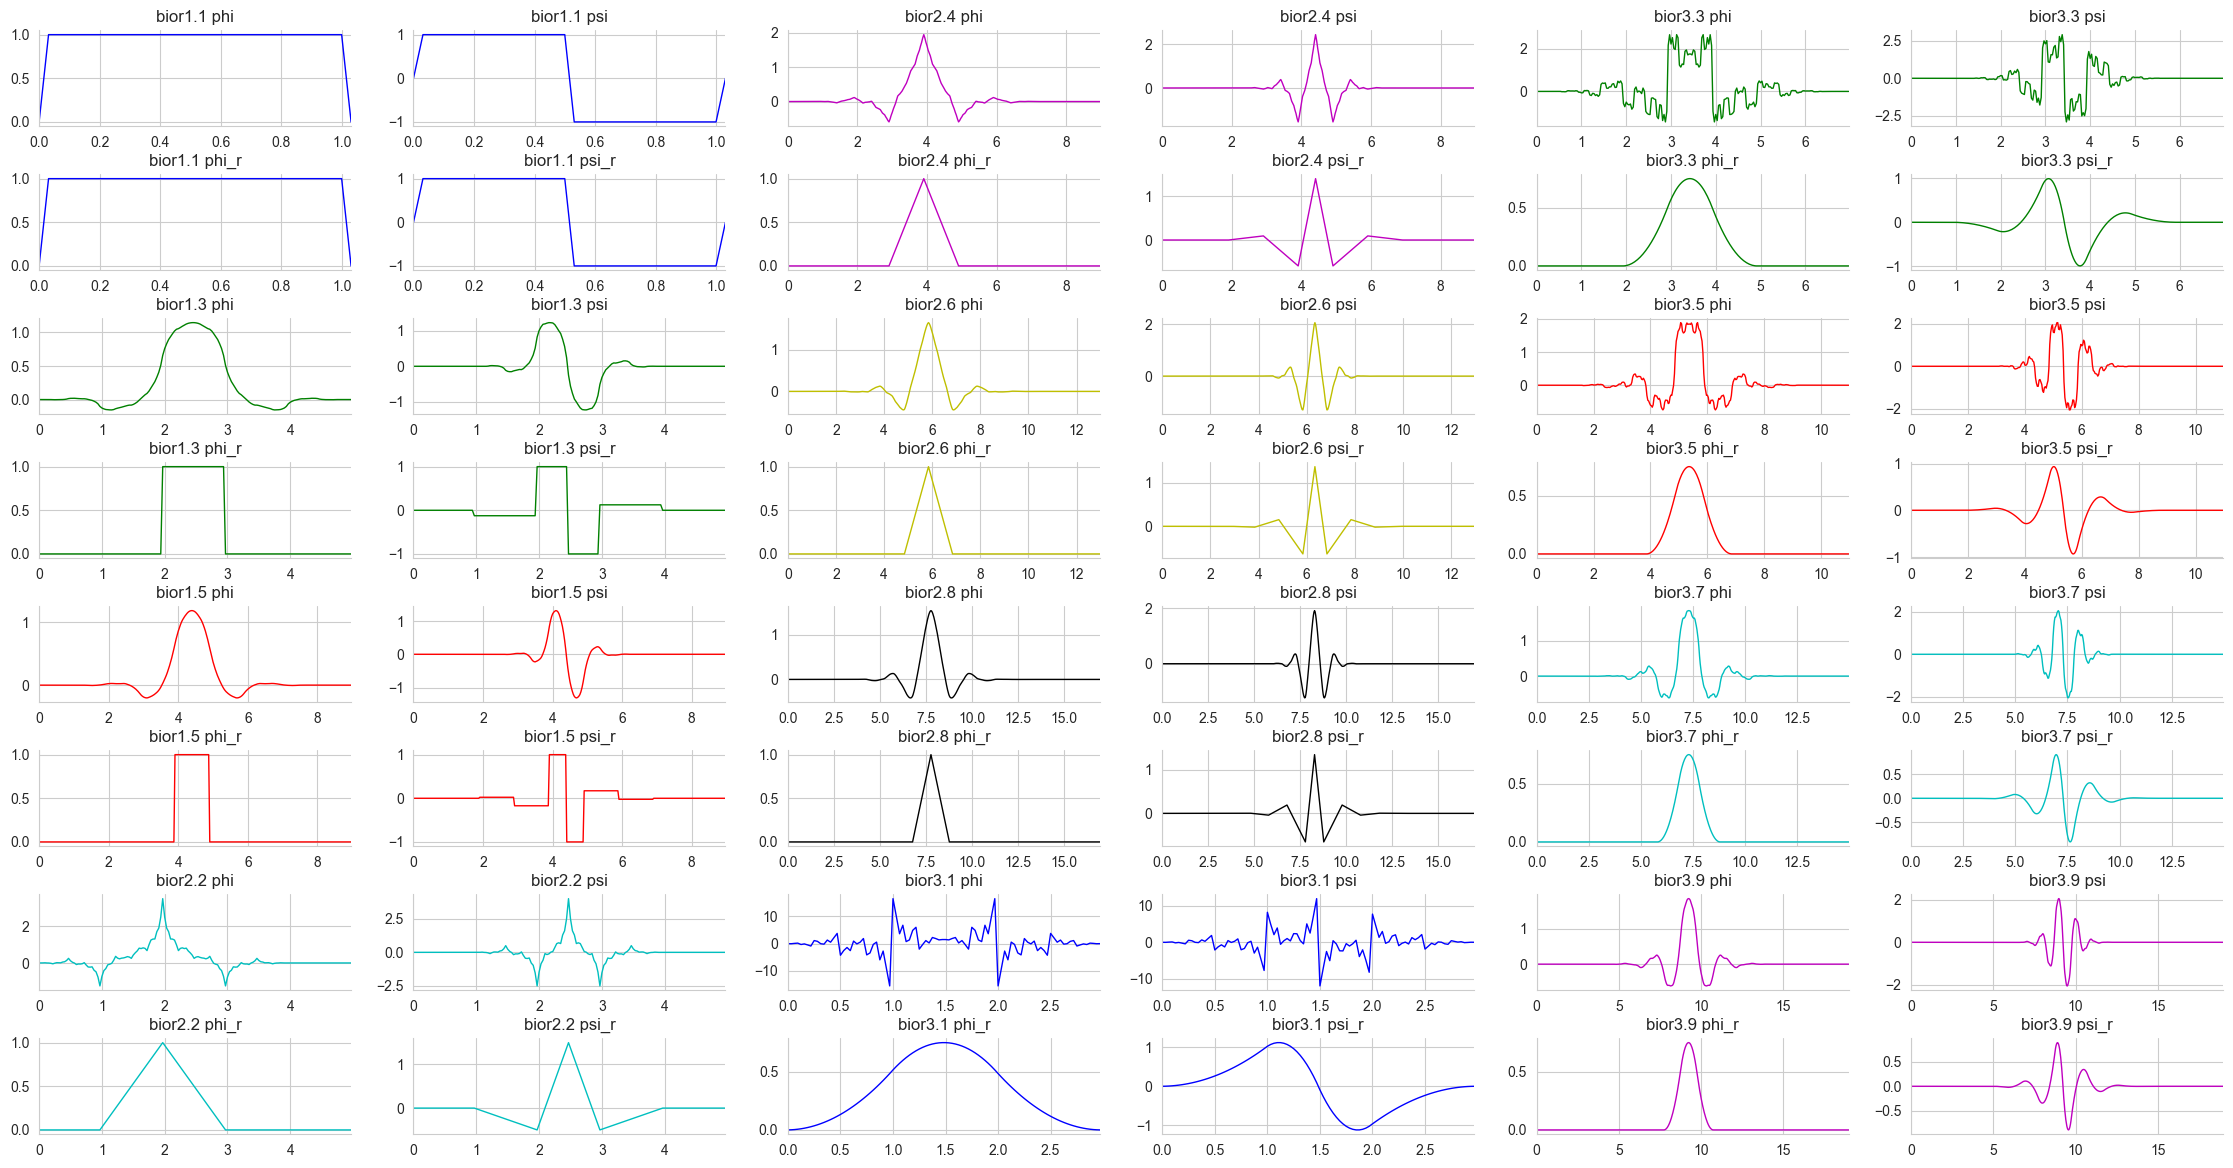

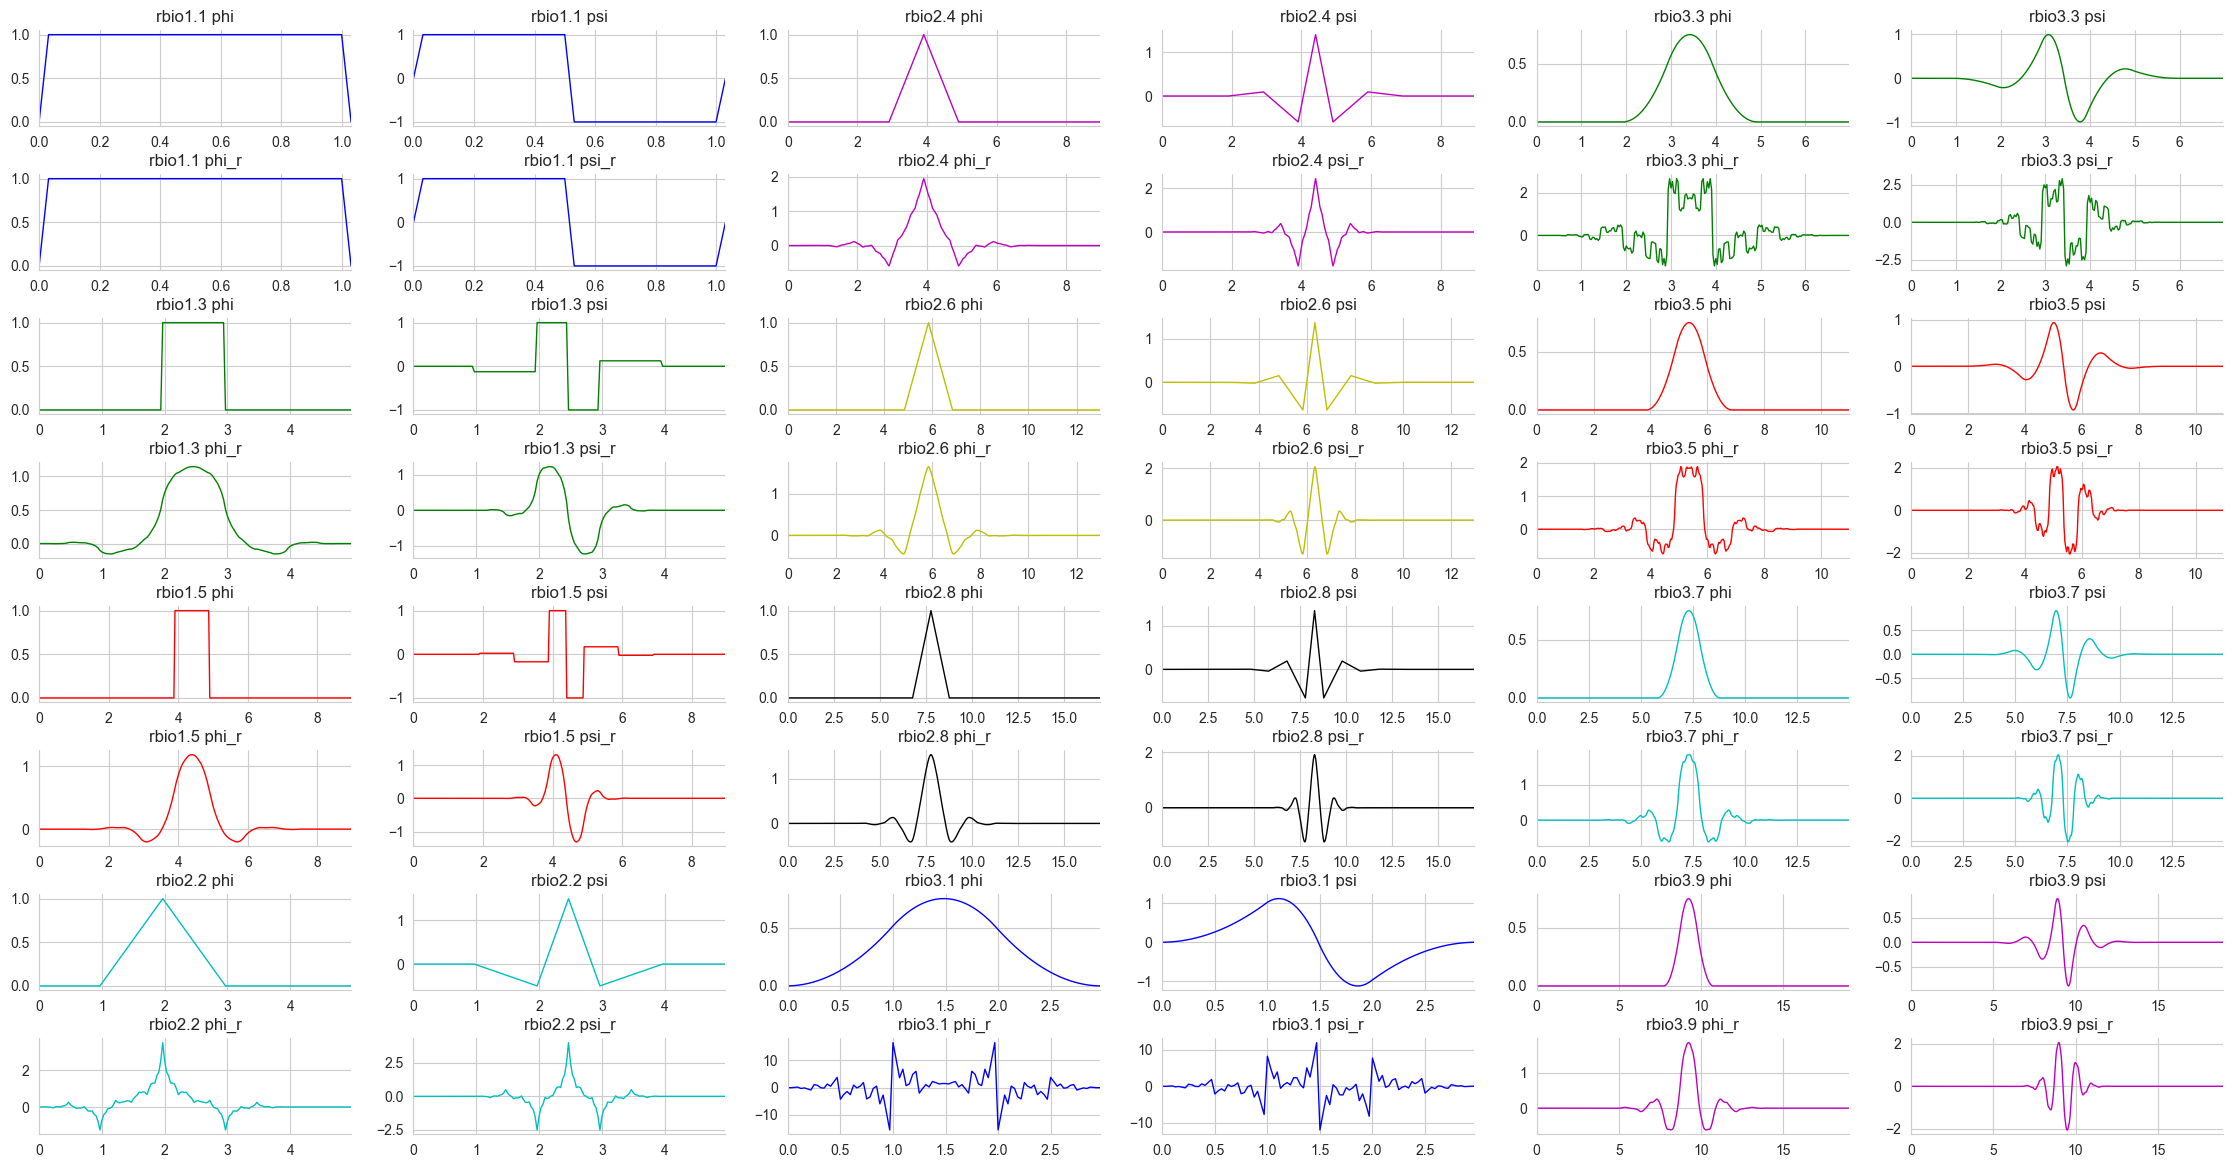

In [38]:
plot_data = [('db', (4, 3)),
             ('sym', (4, 3)),
             ('coif', (3, 2))]


for family, (rows, cols) in plot_data:
    fig = plt.figure(figsize=(24, 12))
    fig.subplots_adjust(hspace=0.2, wspace=0.2, bottom=.02, left=.06,
                        right=.97, top=.94)
    colors = itertools.cycle('bgrcmyk')

    wnames = pywt.wavelist(family)
    i = iter(wnames)
    for col in range(cols):
        for row in range(rows):
            try:
                wavelet = pywt.Wavelet(next(i))
            except StopIteration:
                break
            phi, psi, x = wavelet.wavefun(level=5)

            color = next(colors)
            ax = fig.add_subplot(rows, 2 * cols, 1 + 2 * (col + row * cols))
            ax.set_title(wavelet.name + " phi")
            ax.plot(x, phi, color, lw=1)
            ax.set_xlim(min(x), max(x))

            ax = fig.add_subplot(rows, 2*cols, 1 + 2*(col + row*cols) + 1)
            ax.set_title(wavelet.name + " psi")
            ax.plot(x, psi, color, lw=1)
            ax.set_xlim(min(x), max(x))
    sns.despine()

for family, (rows, cols) in [('bior', (4, 3)), ('rbio', (4, 3))]:
    fig = plt.figure(figsize=(24, 12))
    fig.subplots_adjust(hspace=0.5, wspace=0.2, bottom=.02, left=.06,
                        right=.97, top=.94)

    colors = itertools.cycle('bgrcmyk')
    wnames = pywt.wavelist(family)
    i = iter(wnames)
    for col in range(cols):
        for row in range(rows):
            try:
                wavelet = pywt.Wavelet(next(i))
            except StopIteration:
                break
            phi, psi, phi_r, psi_r, x = wavelet.wavefun(level=5)
            row *= 2

            color = next(colors)
            ax = fig.add_subplot(2*rows, 2*cols, 1 + 2*(col + row*cols))
            ax.set_title(wavelet.name + " phi")
            ax.plot(x, phi, color, lw=1)
            ax.set_xlim(min(x), max(x))

            ax = fig.add_subplot(2*rows, 2*cols, 2*(1 + col + row*cols))
            ax.set_title(wavelet.name + " psi")
            ax.plot(x, psi, color, lw=1)
            ax.set_xlim(min(x), max(x))

            row += 1
            ax = fig.add_subplot(2*rows, 2*cols, 1 + 2*(col + row*cols))
            ax.set_title(wavelet.name + " phi_r")
            ax.plot(x, phi_r, color, lw=1)
            ax.set_xlim(min(x), max(x))

            ax = fig.add_subplot(2*rows, 2*cols, 1 + 2*(col + row*cols) + 1)
            ax.set_title(wavelet.name + " psi_r")
            ax.plot(x, psi_r, color, lw=1)
            ax.set_xlim(min(x), max(x))
    sns.despine()

plt.show()

#### Available Wavelet Families

In [39]:
pywt.families(short=False)

['Haar',
 'Daubechies',
 'Symlets',
 'Coiflets',
 'Biorthogonal',
 'Reverse biorthogonal',
 'Discrete Meyer (FIR Approximation)',
 'Gaussian',
 'Mexican hat wavelet',
 'Morlet wavelet',
 'Complex Gaussian wavelets',
 'Shannon wavelets',
 'Frequency B-Spline wavelets',
 'Complex Morlet wavelets']

#### Smoothing AAPL Stock Returns

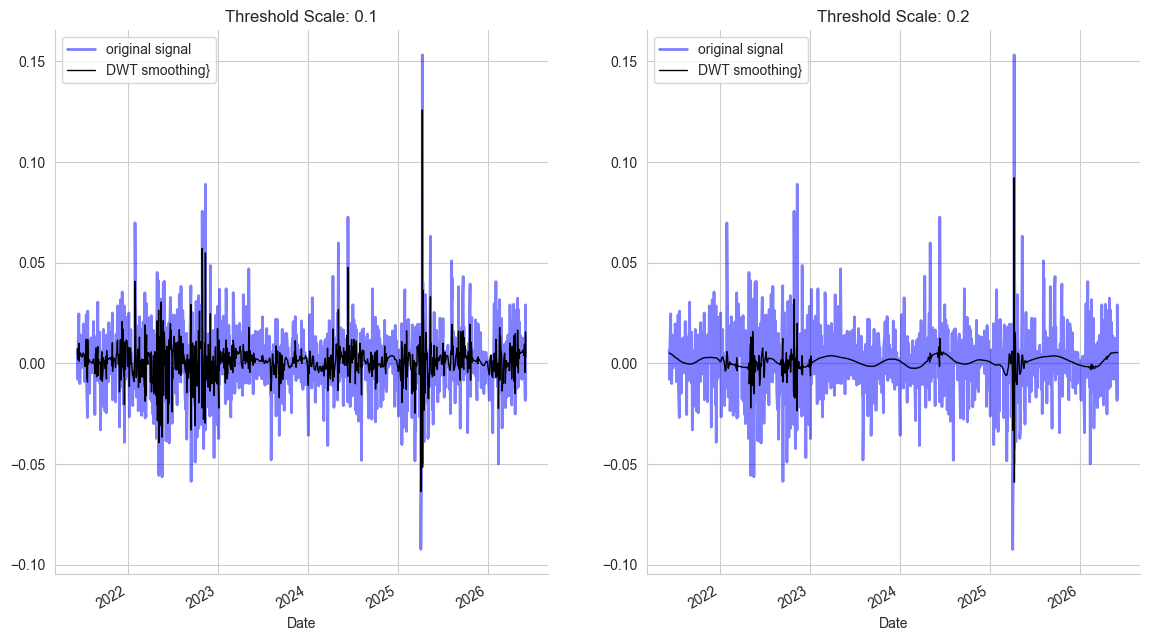

In [49]:
signal = stock_data['AAPL']['returns'].dropna()

fix, axes = plt.subplots(1, 2, figsize=(14, 8))

wavelet = 'db6'

for i, scale in enumerate([.1, .25]):
    
    coefficients = pywt.wavedec(signal.values.copy(), wavelet, mode='per')
    coefficients[1:] = [pywt.threshold(i, value=scale*signal.max(), mode='soft') for i in coefficients[1:]]
    reconstructed_signal = pywt.waverec(coefficients, wavelet, mode='per')
    signal.plot(color="b", alpha=0.5, label='original signal', lw=2, 
                 title=f'Threshold Scale: {scale:.1f}', ax=axes[i])
    pd.Series(reconstructed_signal[:len(signal)], index=signal.index).plot(c='k', label='DWT smoothing}', linewidth=1, ax=axes[i])
    axes[i].legend()
fig.tight_layout()
sns.despine();